# Genomics AI Workshop

## Part 1 — DeepVariant: finding genetic variants in sequencing reads with Neural Networks

Any person's genome differs from the human reference genome at roughly 4–5 million positions, mostly single-nucleotide variants (SNVs) and small insertions/deletions (indels). Finding these differences is called *variant calling*. It is the first step for diagnosing genetic disease, pharmacogenomics and population genetics. A sequencer does not read a genome end to end: it produces millions of reads that are aligned to the reference. At every position where reads disagree with the reference, a caller has to decide two things:
1. Is this a real variant, or a sequencing or alignment error?
2. If real, what is the **genotype**: heterozygous (`0/1`, one of the two chromosome copies carries it) or homozygous (`1/1`, both copies do)?

**Dataset.** 

HG003 is the father in the Genome in a Bottle (GIAB) Ashkenazi trio. It is a reference sample that NIST characterized with many sequencing technologies. Its v4.2.1 *benchmark* is a truth set of high-confidence variants, plus a BED file of the regions where that truth set can be trusted. Our reads are **PacBio HiFi**: long (~15–20 kb) and highly accurate (>99.9% per base). To keep the run short we use one 500 kb window of chromosome 20. Chromosome 20 is held out of DeepVariant's training data, so this is a fair test.

**DeepVariant** 

It treats variant calling as an image-classification problem, in three stages:
1. First, it scans the alignments for *candidate* sites where reads disagree with the reference. For each candidate it turns the reads around that site into a multi-channel "pileup image": each row is a read, each column a position, and channels encode the base, base quality, mapping quality, strand, and whether the read supports the alternative allele. For long reads, the reads are grouped by **haplotype** , so the network sees the two copies separately.
2. Then, it runs a convolutional neural network on each "image". It outputs three probabilities: homozygous reference, heterozygous, homozygous alternative.
3. In the end, converts those probabilities into a **VCF** (variant calls, genotypes and quality scores) and a **gVCF** (which also records confidence at non-variant positions, needed for combining many samples later).

**Difference from `bcftools`** 

`bcftools mpileup | bcftools call` is based on a statistical model. It counts the reads supporting each allele and turns their base qualities into genotype likelihoods, with the assumption that every read error is independent and that the sequencer's reported quality is accurate. Then, it combines the likelihoods with a prior and picks the most likely genotype. False positives are removed afterwards with hand-tuned filters (depth, QUAL, strand bias…). Those assumptions break where errors are *systematic*: homopolymer runs in long reads, reads mis-mapped in duplicated regions, indels that can be aligned in several equivalent ways.

DeepVariant writes down no error model. It **learns** what real variants and artifacts look like from training data where the truth is known. Therefore, it has model per technology (`--model_type WGS`, `WES`, `PACBIO`, `ONT_R104`, `HYBRID_PACBIO_ILLUMINA`). Moving to a new sequencing platform means retraining rather than re-tuning filters. The cost is more compute (a GPU helps) and a decision process that is harder to inspect than a likelihood formula.

Below we call variants in the test window with DeepVariant, then score the calls against the GIAB truth set with **hap.py**, the standard benchmarking tool.

In [1]:
import os
W  = "/projects/bccu/wge2/genomics_ai_workshop"         
DV = f"{W}/data/deepvariant"

cfg = {
    "SIF":        f"{W}/containers/deepvariant_1.10.0.sif",
    "HAPPY_SIF":  f"{W}/containers/happy.sif",
    "INPUT_DIR":  f"{DV}/input",
    "OUTPUT_DIR": f"{DV}/output",
    "REF":        "GRCh38_no_alt_analysis_set.fasta",
    "BAM":        "HG003.SPRQ.pacbio.GRCh38.nov2024.chr20.bam",
    "TRUTH_VCF":  "HG003_GRCh38_1_22_v4.2.1_benchmark.vcf.gz",
    "TRUTH_BED":  "HG003_GRCh38_1_22_v4.2.1_benchmark_noinconsistent.bed",
    "REGION":     "chr20:10000000-10500000",   # quick test; "chr20" for the full chromosome
    "OUT_VCF":    "HG003_PACBIO_SPRQ_GRCh38.test.vcf.gz",
    "OUT_GVCF":   "HG003_PACBIO_SPRQ_GRCh38.test.g.vcf.gz",
    "HAPPY_PREFIX": "hg003.pacbio.happy.output",
    "NSHARDS":    str(os.environ.get("SLURM_CPUS_PER_TASK") or len(os.sched_getaffinity(0))),
}
os.environ.update(cfg)                   # so the %%bash cells below can use them
os.makedirs(cfg["OUTPUT_DIR"], exist_ok=True)
print("CPUs used by DeepVariant:", cfg["NSHARDS"])

CPUs used by DeepVariant: 16


### 1.1 Run DeepVariant from a container

In [2]:
%%bash
# Full DeepVariant output goes to a log file; only a short summary is shown here.
LOG="$OUTPUT_DIR/deepvariant.log"
apptainer run --cleanenv \
  -B "$INPUT_DIR","$OUTPUT_DIR" \
  "$SIF" \
  /opt/deepvariant/bin/run_deepvariant \
    --model_type PACBIO \
    --ref "$INPUT_DIR/$REF" \
    --reads "$INPUT_DIR/$BAM" \
    --regions "$REGION" \
    --output_vcf "$OUTPUT_DIR/$OUT_VCF" \
    --output_gvcf "$OUTPUT_DIR/$OUT_GVCF" \
    --num_shards "$NSHARDS" \
    --vcf_stats_report=true \
    --intermediate_results_dir "$OUTPUT_DIR/intermediate_results_dir" > "$LOG" 2>&1 \
  || { echo "DeepVariant FAILED. Last lines of $LOG:"; tail -n 25 "$LOG"; exit 1; }

echo "DeepVariant finished. Time per stage:"
awk '/^time /{match($0,/make_examples|call_variants|postprocess_variants/); stage=substr($0,RSTART,RLENGTH)} /^real[[:space:]]+[0-9]+m/{printf "  %-20s %s\n", stage, $2}' "$LOG"
awk '/candidate variants found/{n+=$1} END{print n " candidate sites where the reads differ from the reference"}' "$LOG"
awk '/Count of reads with phase 1/{a=$NF} /Count of reads with phase 2/{b=$NF} /Count of reads not phased/{u=$NF} END{if (a != "") print "Reads assigned to chromosome copy 1 / 2 (whole region): " a " / " b " (" u " could not be assigned)"}' "$LOG"
echo "Full log: $LOG"

DeepVariant finished. Time per stage:
  make_examples        0m14.986s
  call_variants        0m16.235s
  postprocess_variants 0m8.690s
                       0m6.710s
1356 candidate sites where the reads differ from the reference
Reads assigned to chromosome copy 1 / 2 (whole region): 591 / 554 (185 could not be assigned)
Full log: /projects/bccu/wge2/genomics_ai_workshop/data/deepvariant/output/deepvariant.log


In [3]:
import pysam, statistics
from collections import Counter

chrom, span = cfg["REGION"].split(":")
start, end = (int(x) for x in span.replace(",", "").split("-"))

lens, hp = [], Counter()
with pysam.AlignmentFile(f"{cfg['INPUT_DIR']}/{cfg['BAM']}") as bam:
    for r in bam.fetch(chrom, start, end):
        if r.is_unmapped or r.is_secondary or r.is_supplementary:
            continue                                  # count each read once
        lens.append(r.query_length)
        hp[r.get_tag("HP") if r.has_tag("HP") else "none"] += 1

print(f"{len(lens)} reads overlap {cfg['REGION']}")
print(f"Read length: median {statistics.median(lens):,.0f} bp, mean {statistics.mean(lens):,.0f} bp, "
      f"min {min(lens):,}, max {max(lens):,}")
print("HP tag (haplotype label already in the input BAM):", dict(hp) if set(hp) != {"none"} else "not present")


ModuleNotFoundError: No module named 'pysam'

### 1.1b DeepVariant result

A *candidate* is any place where some reads differ from the reference. Most are sequencing noise, so DeepVariant's network keeps only the ones that look like real variants (`PASS`). For each kept variant it also decides the genotype: **heterozygous** (only one of the two parental chromosome copies carries the variant) or **homozygous** (both copies do).

PacBio reads are 15 kb or longer, so one read often covers several heterozygous variants. DeepVariant uses this to tell which parental copy (haplotype 1 or 2) each read came from. The roughly even split between the two haplotypes printed above is what a diploid genome should give.

In [ ]:
import pysam
from collections import Counter

chrom, span = cfg["REGION"].split(":")
start, end = (int(x) for x in span.replace(",", "").split("-"))
region_kb = (end - start + 1) / 1000

TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
n = Counter()
for r in pysam.VariantFile(f"{cfg['OUTPUT_DIR']}/{cfg['OUT_VCF']}"):
    gt = r.samples[0]["GT"]
    if "PASS" not in r.filter.keys() or None in gt:
        continue                                   # skip RefCall: a site that was checked and judged not a variant
    ref, alt = r.ref, r.alts[0]
    if len(ref) == len(alt) == 1:
        n["SNV"] += 1
        n["transition" if (ref, alt) in TRANSITIONS else "transversion"] += 1
    else:
        n["insertion" if len(alt) > len(ref) else "deletion"] += 1
    n["het" if len(set(gt)) > 1 else "hom"] += 1

total = n["SNV"] + n["insertion"] + n["deletion"]
assert total, "No PASS variants found - check the DeepVariant log"
print(f"{cfg['REGION']}  ({region_kb:.0f} kb)")
print(f"Variants called (PASS): {total}  ->  about 1 per {1000 * region_kb / total:.0f} bp")
print(f"  SNVs {n['SNV']} ({n['SNV'] / total:.0%})  |  insertions {n['insertion']}  |  deletions {n['deletion']}")
print(f"  heterozygous {n['het']}  |  homozygous {n['hom']}   ->  het/hom = {n['het'] / max(n['hom'], 1):.2f}")
print(f"  Ti/Tv of SNVs = {n['transition'] / max(n['transversion'], 1):.2f}")
print("""
For comparison, a typical human genome (vs GRCh38):
  density    ~1 variant per 600-800 bp (4-5 million per genome), but it varies a lot between regions
  SNV share  ~85-90% of variants; the rest are small insertions and deletions
  Ti/Tv      ~2.0-2.1. Transitions (A<->G, C<->T) are favoured by the biology of mutation
             (for example deamination of methylated cytosines); random errors would give ~0.5
  het/hom    ~1.5 in many European-ancestry genomes, higher in African-ancestry genomes
A window of 500 kb has only a few hundred variants, so these ratios are noisy: use them as a sanity check, not a measurement.""")

### 1.2 Benchmark against the GIAB truth set (hap.py)

In [ ]:
%%bash
LOG="$OUTPUT_DIR/happy.log"
apptainer run --cleanenv \
  -B "$INPUT_DIR","$OUTPUT_DIR" \
  "$HAPPY_SIF" /opt/hap.py/bin/hap.py \
    "$INPUT_DIR/$TRUTH_VCF" \
    "$OUTPUT_DIR/$OUT_VCF" \
    -f "$INPUT_DIR/$TRUTH_BED" \
    -r "$INPUT_DIR/$REF" \
    -o "$OUTPUT_DIR/$HAPPY_PREFIX" \
    -l "$REGION" \
    --engine=vcfeval --pass-only \
    --scratch-prefix "$OUTPUT_DIR" > "$LOG" 2>&1 \
  || { echo "hap.py FAILED. Last lines of $LOG:"; tail -n 25 "$LOG"; exit 1; }
echo "hap.py finished. Full log: $LOG"

In [ ]:
# What did hap.py find? Error types and biological sanity checks (PASS calls only).
import pandas as pd
from IPython.display import display

happy = pd.read_csv(f"{cfg['OUTPUT_DIR']}/{cfg['HAPPY_PREFIX']}.summary.csv")
m = happy[happy["Filter"] == "PASS"].set_index("Type")

# 1) Where do the errors come from?
#    FN = true variants missed; FP.gt = right site, wrong genotype (e.g. het called hom);
#    FP.al = wrong allele; UNK = calls outside the confident regions (not judged).
errors = ["TRUTH.TOTAL", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP", "FP.gt", "FP.al", "QUERY.UNK"]
display(m[[c for c in errors if c in m.columns]])

# 2) Does the call set look biologically plausible? Compare query (ours) with truth.
#    Ti/Tv is ~2.0-2.1 genome-wide (transitions outnumber transversions); random errors pull it toward 0.5.
#    Het/hom should be close to truth; a skew points to systematic genotyping bias.
checks = ["TRUTH.TOTAL.TiTv_ratio", "QUERY.TOTAL.TiTv_ratio",
          "TRUTH.TOTAL.het_hom_ratio", "QUERY.TOTAL.het_hom_ratio"]
display(m[[c for c in checks if c in m.columns]].round(2))

# 3) One-line reading per variant type.
for t, r in m.iterrows():
    fn, fp = int(r["TRUTH.FN"]), int(r["QUERY.FP"])
    print(f"{t}: missed {fn} of {int(r['TRUTH.TOTAL'])} true variants; "
          f"{fp} of {int(r['QUERY.TOTAL'])} calls not in truth "
          f"(genotype errors: {int(r.get('FP.gt', 0))}, allele errors: {int(r.get('FP.al', 0))}).")


### 1.3 Output VCF processing
DeepVariant writes its own HTML report of the calls next to the VCF.

In [ ]:
import glob, html, subprocess
from IPython.display import HTML, display

out = cfg["OUTPUT_DIR"]
hits = glob.glob(f"{out}/*.visual_report.html")

if not hits:
    # run_deepvariant did not leave a report (older/newer image, or the report step was skipped).
    # Build it from the final VCF with the stats tool that ships in the same container.
    vcf = f"{out}/{cfg['OUT_VCF']}"
    base = vcf[:-len(".vcf.gz")]
    r = subprocess.run(
        ["apptainer", "exec", "--cleanenv", "-B", out, cfg["SIF"],
         "/opt/deepvariant/bin/vcf_stats_report",
         "--input_vcf", vcf, "--outfile_base", base],
        capture_output=True, text=True)
    hits = glob.glob(f"{out}/*.visual_report.html")
    if not hits:
        print("Could not create the report. Last output:\n", (r.stdout + r.stderr)[-1500:])
        print("HTML files in output dir:", glob.glob(f"{out}/**/*.html", recursive=True))
        raise FileNotFoundError("no *.visual_report.html in " + out)

report = hits[0]
print("Report:", report)
display(HTML(f'<iframe srcdoc="{html.escape(open(report).read())}" width="100%" height="900" style="border:0"></iframe>'))


Our own summary of the VCF. `PASS` = variant call; `RefCall` = DeepVariant looked at the site and decided it is not a variant.

In [ ]:
import pysam, pandas as pd, matplotlib.pyplot as plt

rows = []
for r in pysam.VariantFile(f"{cfg['OUTPUT_DIR']}/{cfg['OUT_VCF']}"):
    alt = r.alts[0]
    vtype = "SNP" if len(r.ref) == len(alt) == 1 else ("INS" if len(alt) > len(r.ref) else "DEL")
    gt = "/".join("." if a is None else str(a) for a in r.samples[0]["GT"])
    rows.append({"pos": r.pos, "filter": list(r.filter.keys())[0], "type": vtype, "qual": r.qual, "GT": gt})
calls = pd.DataFrame(rows)
passed = calls[calls["filter"] == "PASS"]
print(calls["filter"].value_counts().to_string(), "\n")
print(pd.crosstab(passed["type"], passed["GT"]))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
passed["type"].value_counts().plot.bar(ax=ax[0], title="PASS calls by type")
for f, d in calls.groupby("filter"):
    ax[1].hist(d["qual"], bins=40, alpha=0.6, label=f)
ax[1].set(title="QUAL: PASS vs RefCall", xlabel="QUAL"); ax[1].legend()
for t, d in passed.groupby("type"):
    ax[2].scatter(d["pos"] / 1e6, d["qual"], s=8, label=t)
ax[2].set(title="PASS calls along the region", xlabel=f"{cfg['REGION'].split(':')[0]} position (Mb)", ylabel="QUAL"); ax[2].legend()
plt.tight_layout()

Then let's evaluate the output

In [ ]:
happy = pd.read_csv(f"{cfg['OUTPUT_DIR']}/{cfg['HAPPY_PREFIX']}.summary.csv")
m = happy[happy["Filter"] == "PASS"].set_index("Type")
display(m[["TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.FP", "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]])

metrics = m[["METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]]
ax = metrics.plot.bar(figsize=(6, 4), rot=0, title="DeepVariant vs GIAB truth")
ax.set_ylim(max(0, metrics.values.min() - 0.05), 1.0)

### Limitations of this toy example

On 500 kb of high-quality HiFi data in a mostly easy region, almost any modern caller scores close to 100%. DeepVariant's advantages show up at larger scale and in harder settings:

- **Indels and difficult sequence.** The gap between DeepVariant and classical callers is largest for indels, homopolymers, tandem repeats and segmental duplications, where sequencing and mapping errors are systematic rather than random. Running hap.py genome-wide with GIAB's *stratification* BED files (low-complexity regions, segmental duplications, the MHC) breaks accuracy down by region type and makes this visible. DeepVariant won the SNP accuracy award in the 2016 precisionFDA Truth Challenge, and DeepVariant-based entries took several categories of the 2020 Truth Challenge V2, including difficult-to-map regions.
- **One method across technologies.** The same pipeline gives top-tier accuracy on Illumina, PacBio HiFi and Oxford Nanopore data, or a hybrid of short and long reads, without per-platform filter engineering. It can also be retrained for a new chemistry or a non-human species.
- **Families and cohorts.** **DeepTrio** calls a child together with both parents. That improves accuracy and helps find *de novo* mutations, the main cause of many rare pediatric diseases. HG003 is one of those parents: the full trio is HG002, HG003 and HG004. The gVCF output can be merged across thousands of samples with **GLnexus** for population studies. **DeepSomatic** extends the approach to tumor/normal pairs for cancer.
- **Scale.** A whole genome yields ~4–5 million variants instead of the few hundred here, and small precision differences become thousands of false calls that someone would have to chase in a clinical report.

**Limits to keep in mind:** DeepVariant calls *small* germline variants (SNVs and indels up to ~50 bp) and assumes a diploid genome. Structural variants, copy-number changes and repeat expansions need other tools (for example Sniffles or pbsv for long reads).

**Try it when you have time** set `REGION = "chr20"` in the settings cell to run the whole chromosome. It takes longer, but the indel numbers and the hap.py metrics become more informative.

## Part 2 — Enformer: predicting gene regulation from DNA sequence

Part 1 found the variants in a genome. Most of them, and over 90% of disease-associated variants from genome-wide association studies (GWAS), fall *outside* protein-coding genes, in the ~98% of the genome that does not code for protein. Their effect comes from changing **gene regulation**: where, when and how strongly a gene is switched on. That regulation is written in the DNA as short sequence *motifs* recognized by transcription factors. The motifs sit in **promoters** (right at a gene's transcription start site, TSS) and **enhancers**, which can be tens of kilobases away from the gene they control. Reading that code from sequence alone is a central open problem in genomics.

**Enformer** 

Enformer (Avsec et al., *Nature Methods* 2021) takes **196,608 bp** of DNA sequence. For the central **114,688 bp**, in 896 bins of 128 bp, it predicts **5,313 human genomic tracks** (plus 1,643 mouse tracks) measured by ENCODE, Roadmap and FANTOM5 across hundreds of cell types:

| Assay | What it measures | Biological meaning |
|---|---|---|
| **DNase-seq / ATAC-seq** | Which DNA is accessible (not packed into nucleosomes) | Where regulatory elements are active and TFs can bind |
| **ChIP-seq** | Where a histone mark or transcription factor sits | e.g. H3K27ac marks active enhancers and promoters; H3K4me3 marks promoters |
| **CAGE** | Where RNA transcription starts, and how much | Promoter activity, a proxy for gene expression |

**Structure**
1. **Convolutional layers** scan the sequence for motifs and compress it into 128-bp bins.
2. **Transformer layers** (attention, as in language models) let every bin look at every other bin across the ~100 kb window. This is how a distal enhancer can influence the prediction at a promoter, and it is Enformer's main advance over earlier convolution-only models such as Basenji2 (around 20 kb reach). The name is *enhancer* + *transformer*.
3. **One output head per species** turns the shared representation into the experimental tracks.

The model was trained only on the **reference genome** and the measured tracks. It has never seen a variant; any variant effect we compute is a prediction of how the sequence change alters these signals.

We use the PyTorch port [`enformer-pytorch`](https://github.com/lucidrains/enformer-pytorch) with the official weights converted by EleutherAI (`enformer-official-rough`). Its accuracy is very close to the original TensorFlow model. The steps follow Google's [enformer-usage](https://colab.research.google.com/github/deepmind/deepmind-research/blob/master/enformer/enformer-usage.ipynb) demo.

### 2.1 Load the model, the reference genome and the track list (very slow)

In [4]:
import os, time
_t = time.time()
def lap(msg):
    global _t
    print(f"{time.time() - _t:6.1f}s  {msg}"); _t = time.time()

os.environ.setdefault("HF_HUB_OFFLINE", "1")   # weights are cached by download_data.sh; never wait on the network
import numpy as np, pandas as pd;           lap("import numpy, pandas")
import matplotlib.pyplot as plt;            lap("import matplotlib")
import torch;                               lap("import torch")
import pyfaidx;                             lap("import pyfaidx")
from enformer_pytorch import from_pretrained; lap("import enformer_pytorch")

n_cpu = len(os.sched_getaffinity(0))
torch.set_num_threads(n_cpu)
mem = os.environ.get("SLURM_MEM_PER_NODE") or os.environ.get("SLURM_MEM_PER_CPU")   # MB, set by Slurm
total_gb = int(next(l for l in open("/proc/meminfo") if l.startswith("MemTotal")).split()[1]) / 2**20
print(f"usable CPUs: {n_cpu} | Slurm memory request: {mem} MB | node RAM: {total_gb:.0f} GB | HF_HOME: {os.environ.get('HF_HOME')}")

ENF_DIR = f"{os.environ['WORKSHOP_DIR']}/data/enformer"
SEQ_LEN, N_BINS, BIN = 196_608, 896, 128          # input bp, output bins, bp per bin
OUT_LEN = N_BINS * BIN                            # 114,688 bp of predictions in the centre

device = "cuda" if torch.cuda.is_available() else "cpu"
model = from_pretrained("EleutherAI/enformer-official-rough").to(device).eval()
lap("model loaded")
fasta = pyfaidx.Fasta(f"{ENF_DIR}/hg38.fa")
lap("fasta opened")
targets = pd.read_csv(f"{ENF_DIR}/targets_human.txt", sep="\t")
targets["assay"] = targets["description"].str.split(":").str[0]
lap("targets read")
print("device:", device)
print(targets["assay"].value_counts().to_string())

   2.6s  import numpy, pandas


ModuleNotFoundError: No module named 'matplotlib'

In [5]:
LUT = np.zeros((256, 4), dtype=np.float32)        # A,C,G,T -> one-hot; N -> all zeros
for i, b in enumerate(b"ACGT"):
    LUT[b, i] = 1

def one_hot(seq):
    return LUT[np.frombuffer(seq.encode(), dtype=np.uint8)]

def get_seq(chrom, center, length=SEQ_LEN):
    # length bp of hg38 centred on 0-based position `center`, padded with N past chromosome ends
    start, end, n = center - length // 2, center + length // 2, len(fasta[chrom])
    s = fasta[chrom][max(start, 0):min(end, n)].seq.upper()
    return "N" * max(0, -start) + s + "N" * max(0, end - n)

@torch.no_grad()
def predict(seqs):
    x = torch.from_numpy(np.stack([one_hot(s) for s in seqs])).to(device)
    return model(x)["human"].cpu().numpy()      # (batch, 896 bins, 5313 tracks)

def track(prefix):
    # index of the first track whose description starts with `prefix`
    return int(targets.index[targets["description"].str.startswith(prefix)][0])

def plot_tracks(tracks, start, end, marks=(), ylabel=None):
    fig, axes = plt.subplots(len(tracks), 1, figsize=(14, 1.5 * len(tracks)), sharex=True)
    for ax, (name, y) in zip(np.atleast_1d(axes), tracks.items()):
        ax.fill_between(np.linspace(start, end, len(y)), y, color="tab:blue")
        ax.set_title(name, loc="left", fontsize=9)
        for m in marks:
            ax.axvline(m, color="tab:red", lw=0.8, ls="--")
        ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_xlabel(f"{chrom} position (hg38, bp)")
    plt.tight_layout()

NameError: name 'SEQ_LEN' is not defined

### 2.2 Predict regulatory activity around a gene: *CD44*

*CD44* encodes a cell-surface receptor for hyaluronic acid, involved in cell adhesion and migration. It is strongly expressed in immune cells such as monocytes and in skin keratinocytes, and is studied as a marker of cancer stem cells. We use the same 114,688 bp window on chromosome 11 as Google's demo, which covers the *CD44* promoter.

We plot the same three assays in **two cell types**. Things to look for:
- Accessibility (DNase), the active mark (H3K27ac) and transcription start (CAGE) should **line up** at an active promoter. Peaks with DNase and H3K27ac but little CAGE are candidate **enhancers**.
- Peaks present in one cell type but not the other are **cell-type-specific** regulatory elements. The model learned these differences from sequence alone: the input DNA is identical for both cell types.

In [6]:
chrom, win_start, win_end = "chr11", 35_082_742, 35_197_430     # 114,688 bp output window
center = (win_start + win_end) // 2
pred = predict([get_seq(chrom, center)])[0]

cage_k = track("CAGE:Keratinocyte - epidermal")
tss_bin = N_BINS // 2 - 20 + int(np.argmax(pred[N_BINS // 2 - 20 : N_BINS // 2 + 20, cage_k]))
tss_pos = win_start + tss_bin * BIN
print(f"strongest predicted keratinocyte CAGE signal near the window centre: {chrom}:{tss_pos:,} (bin {tss_bin})")

show = {
    "DNASE:CD14-positive monocyte female": "DNase · monocyte",
    "DNASE:keratinocyte female": "DNase · keratinocyte",
    "CHIP:H3K27ac:CD14-positive monocyte female": "H3K27ac · monocyte",
    "CHIP:H3K27ac:keratinocyte female": "H3K27ac · keratinocyte",
    "CAGE:CD14+ Monocytes": "CAGE (log10) · monocyte",
    "CAGE:Keratinocyte - epidermal": "CAGE (log10) · keratinocyte",
}
tracks = {}
for prefix, label in show.items():
    y = pred[:, track(prefix)]
    tracks[label] = np.log10(1 + y) if prefix.startswith("CAGE") else y
plot_tracks(tracks, win_start, win_end, marks=[tss_pos])

NameError: name 'predict' is not defined

### 2.3 Contribution scores - finding important bases

For every base in the 196 kb input: if this base changed, how much would the predicted CAGE signal at the *CD44* TSS change? Bases with large scores are the ones the model "reads".
- **Across the whole window**, clusters of high scores far from the TSS are the model's candidate **enhancers** for *CD44*. In the Enformer paper, such scores agreed with enhancer–gene links validated by CRISPR interference screens.
- **Zoomed in on the promoter**, high-scoring bases tend to form short runs: these are **transcription-factor binding motifs**. The model was never told what a motif is; it found them because they predict the data.

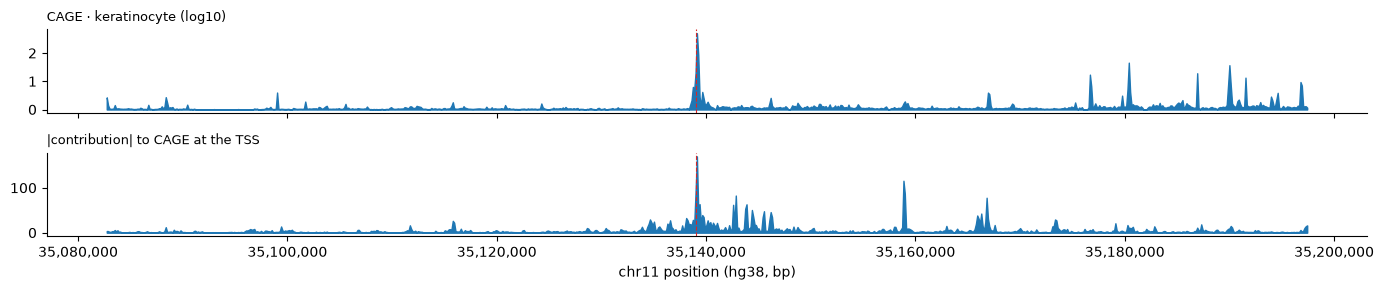

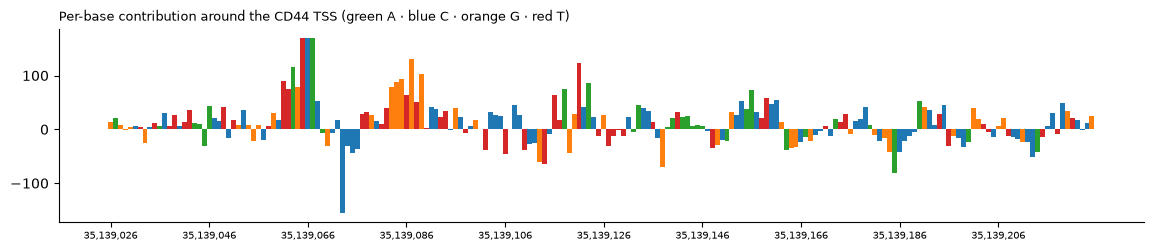

In [15]:
x = torch.from_numpy(one_hot(get_seq(chrom, center))[None]).to(device).requires_grad_(True)
out = model(x)["human"]
out[0, tss_bin - 1 : tss_bin + 2, cage_k].sum().backward()       # CAGE at the TSS bins
contrib = (x.grad * x).sum(-1)[0].detach().cpu().numpy()          # one score per input base

# whole output window, max |score| per 128-bp bin
offset = (SEQ_LEN - OUT_LEN) // 2
window = np.abs(contrib[offset : offset + OUT_LEN]).reshape(N_BINS, BIN).max(1)
plot_tracks({"CAGE · keratinocyte (log10)": np.log10(1 + pred[:, cage_k]),
             "|contribution| to CAGE at the TSS": window}, win_start, win_end, marks=[tss_pos])

# zoom: ±100 bp around the TSS bin, one bar per base coloured by nucleotide
i0 = offset + tss_bin * BIN + BIN // 2 - 100
seg, bases = contrib[i0 : i0 + 200], get_seq(chrom, center)[i0 : i0 + 200]
colors = {"A": "tab:green", "C": "tab:blue", "G": "tab:orange", "T": "tab:red", "N": "grey"}
plt.figure(figsize=(14, 2.5))
plt.bar(np.arange(200), seg, color=[colors[b] for b in bases], width=1.0)
plt.xticks(np.arange(0, 200, 20), [f"{win_start - SEQ_LEN // 2 + OUT_LEN // 2 + i0 + k:,}" for k in range(0, 200, 20)], fontsize=7)
plt.title("Per-base contribution around the CD44 TSS (green A · blue C · orange G · red T)", loc="left", fontsize=9)
plt.gca().spines[["top", "right"]].set_visible(False)

### 2.4 Predict the effect of clinical variants

To score a variant we run the model twice, on the reference sequence and on the same sequence carrying the alternative allele, and compare the predictions (*in silico* mutagenesis). This is the step that links Part 1 and Part 2: DeepVariant tells us *which* bases differ in a genome, and Enformer suggests *what* a non-coding difference might do to regulation.

We take a few single-nucleotide variants from **ClinVar**, the NCBI database of variants with a clinical interpretation, that sit in **5′ untranslated regions** (5′UTRs, the start of a gene's mRNA, right next to the promoter). We take some classified *pathogenic* and some *benign*. For each variant we compute, for every track, the log2 fold change (alt vs ref) of the predicted signal in the bins around the variant, and report the track that changes most.

**Expect mixed results.** Many pathogenic 5′UTR variants act on **translation**, for example by creating an upstream start codon in the mRNA. Enformer cannot see that: it only models chromatin and transcription. A low score therefore does not mean "harmless".

In [16]:
import pysam
pysam.set_verbosity(0)                       # ClinVar file has no index; silence the htslib notice

PATHO = {"Pathogenic", "Likely_pathogenic", "Pathogenic/Likely_pathogenic"}
BENIGN = {"Benign", "Likely_benign", "Benign/Likely_benign"}
N_EACH = 4                                   # variants per group; each costs one model run

picked = []
for r in pysam.VariantFile(f"{ENF_DIR}/clinvar.vcf.gz"):
    info = r.info
    if info.get("CLNVC") != "single_nucleotide_variant" or not r.alts:
        continue
    if not any("5_prime_UTR_variant" in m for m in info.get("MC", ())):
        continue
    sig = ",".join(info.get("CLNSIG", ()))
    group = "pathogenic" if sig in PATHO else "benign" if sig in BENIGN else None
    if group is None or sum(p["group"] == group for p in picked) >= N_EACH or f"chr{r.chrom}" not in fasta:
        continue
    picked.append(dict(chrom=f"chr{r.chrom}", pos=r.pos, ref=r.ref, alt=r.alts[0],
                       gene=info.get("GENEINFO", "?").split(":")[0], group=group, clinsig=sig))
    if len(picked) == 2 * N_EACH:
        break

def score_variant(chrom, pos, ref, alt, flank=5):
    # predictions for ref and alt; effect = log2 fold change over the bins around the variant
    c = pos - 1                                              # VCF is 1-based
    ref_seq = get_seq(chrom, c)
    assert ref_seq[SEQ_LEN // 2] == ref.upper(), "reference allele does not match hg38"
    alt_seq = ref_seq[: SEQ_LEN // 2] + alt + ref_seq[SEQ_LEN // 2 + 1 :]
    p_ref, p_alt = predict([ref_seq, alt_seq])
    mid = slice(N_BINS // 2 - flank, N_BINS // 2 + flank + 1)
    lfc = np.log2((p_alt[mid].sum(0) + 1) / (p_ref[mid].sum(0) + 1))
    return p_ref, p_alt, lfc

rows, preds = [], {}
for v in picked:
    p_ref, p_alt, lfc = score_variant(v["chrom"], v["pos"], v["ref"], v["alt"])
    top = int(np.argmax(np.abs(lfc)))
    name = f'{v["gene"]} {v["chrom"]}:{v["pos"]} {v["ref"]}>{v["alt"]}'
    preds[name] = (p_ref, p_alt, top, v["pos"])
    rows.append({"variant": name, "ClinVar": v["clinsig"], "group": v["group"],
                 "max |log2FC|": abs(lfc[top]), "log2FC": lfc[top],
                 "most affected track": targets.loc[top, "description"]})
effects = pd.DataFrame(rows).sort_values("max |log2FC|", ascending=False)
display(effects.style.format({"max |log2FC|": "{:.3f}", "log2FC": "{:+.3f}"}))

,variant,ClinVar,group,max |log2FC|,log2FC,most affected track
6,GNB1 chr1:1804553 C>A,Likely_pathogenic,pathogenic,0.340,-0.340,CHIP:NR2F1:K562
4,INTS11 chr1:1321072 C>A,Pathogenic,pathogenic,0.313,-0.313,CHIP:H3K27ac:myotube
2,ISG15 chr1:1013541 T>C,Benign,benign,0.253,+0.253,CAGE:retinoblastoma cell line:Y79
5,ATAD3A chr1:1516036 T>G,Pathogenic,pathogenic,0.247,-0.247,CHIP:H3K4me1:adrenal gland male embryo (97 days)
0,SAMD11 chr1:925935 G>A,Likely_benign,benign,0.224,+0.224,"CAGE:Renal Cortical Epithelial Cells,"
7,GNB1 chr1:1804560 A>G,Likely_pathogenic,pathogenic,0.170,-0.170,CHIP:H3K4me1:liver female adult (25 years)
3,B3GALT6 chr1:1232241 G>A,Likely_benign,benign,0.134,+0.134,CHIP:PKNOX1:HEK293T
1,PERM1 chr1:981131 C>T,Likely_benign,benign,0.053,-0.053,CHIP:MAX:K562


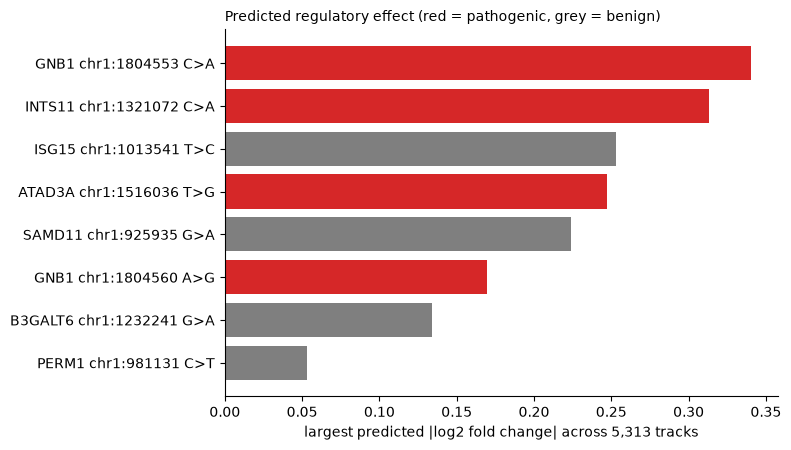

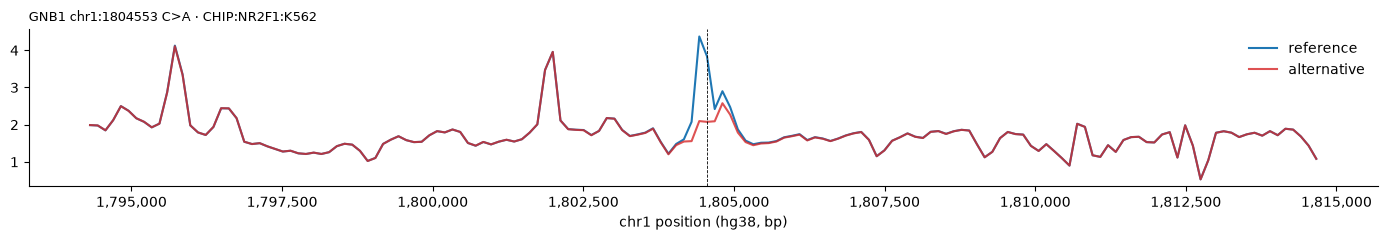

In [17]:
fig, ax = plt.subplots(figsize=(8, 0.45 * len(effects) + 1))
ax.barh(effects["variant"], effects["max |log2FC|"],
        color=effects["group"].map({"pathogenic": "tab:red", "benign": "tab:grey"}))
ax.invert_yaxis(); ax.set_xlabel("largest predicted |log2 fold change| across 5,313 tracks")
ax.set_title("Predicted regulatory effect (red = pathogenic, grey = benign)", loc="left", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

# strongest variant: reference vs alternative prediction for its most affected track, ±10 kb
name = effects.iloc[0]["variant"]
p_ref, p_alt, top, pos = preds[name]
z = slice(N_BINS // 2 - 80, N_BINS // 2 + 80)
xs = pos - OUT_LEN // 2 + np.arange(N_BINS)[z] * BIN
plt.figure(figsize=(14, 2.5))
plt.plot(xs, p_ref[z, top], label="reference", color="tab:blue")
plt.plot(xs, p_alt[z, top], label="alternative", color="tab:red", alpha=0.8)
plt.axvline(pos, color="k", lw=0.6, ls="--")
plt.title(f"{name} · {targets.loc[top, 'description']}", loc="left", fontsize=9)
plt.legend(frameon=False); plt.gca().spines[["top", "right"]].set_visible(False)
plt.gca().ticklabel_format(useOffset=False, style="plain")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.xlabel(f"{name.split()[1].split(':')[0]} position (hg38, bp)"); plt.tight_layout()

### Limitations of this toy example

Enformer's strengths and limits are both broader than a handful of variants at one locus:

- **Prioritizing non-coding variants at scale.** Scoring every variant in a GWAS region or an eQTL set helps narrow thousands of statistically linked candidates down to the few that plausibly change regulation, and suggests the tissue in which they act. In the Enformer paper, its variant scores separated likely causal (fine-mapped) expression-associated variants from nearby non-causal ones better than earlier models.
- **Saturation mutagenesis and enhancer mapping.** Mutating every base of a promoter or enhancer *in silico* gives a full map of which positions and motifs matter. Contribution scores across the 100 kb window propose enhancer–gene links without running an experiment.
- **Cell-type context.** With 5,313 tracks, one prediction gives a rough regulatory picture across hundreds of cell types and tissues. These are hypotheses to test, for example with reporter assays or CRISPR screens.

**Known limits:**
- **Personal genomes.** Benchmarks (Huang et al. and Sasse et al., *Nature Genetics* 2023) found that Enformer and similar models explain little of the expression differences *between individuals*, and often get the direction of a variant's effect wrong. They are much better at "which regions are active" than at "whose expression is higher".
- **Reach.** Regulation beyond ~100 kb is outside the window.
- **What it measures.** Effects on RNA splicing, stability or translation are invisible to it (see the 5′UTR caveat above), and it only knows the cell types it was trained on.
- **Newer models.** Successors extend the idea: **Borzoi** (2025) predicts RNA-seq coverage, adding splicing and transcript processing, over ~524 kb. **AlphaGenome** (2025) works at base-pair resolution over 1 Mb.

## Part 3 — Cellpose: finding single cells in microscopy images

**Segmentation: how does computer "see a cell or a nucleus" in a microscopic image?** 

Cellpose (Stringer *et al.*, *Nature Methods* 2021) takes a microscopy image and draws the outline of every cell or nucleus in it, a task called **cell segmentation**. For each pixel, a neural network predicts whether the pixel lies inside a cell and a **flow**: a direction pointing toward the centre of that cell. Following the flows groups pixels into individual cells, which is how Cellpose separates cells that touch. It is a **generalist**: one model, trained on many kinds of images (cells and nuclei, fluorescence and brightfield, cultured cells and tissue), works on new images without retraining. The current version, **Cellpose-SAM** (Pachitariu, Rariden & Stringer, *bioRxiv* 2025), builds on the image encoder of Meta's Segment Anything Model and no longer needs to be told which channel is which or how large the cells are.

**Downstream analysis** 

A microscopy image is pixels; biology happens in cells. Segmentation is the step that turns an image into a list of cells, each with a position, size, shape and the intensity of every stain or marker inside it. Everything downstream depends on it: counting cells, measuring their morphology, and assigning molecular measurements to individual cells. Errors propagate: two touching cells merged into one mix their signals and can look like a cell type that does not exist; one cell split in two inflates counts and distorts sizes.

After segmentation, the downstream models are finally possible: identifying cell types/tissue types, subtyping diseases, finding immuno-cell aggregation, evaluating treatment examples...

**Try it yourself.** The official Cellpose-SAM tutorial runs in Google Colab on example data in 2D and 3D:
- Tutorial notebook: https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/test_Cellpose-SAM.ipynb
- Run on your own images: https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/run_Cellpose-SAM.ipynb
- Documentation: https://cellpose.readthedocs.io/en/latest/